In [ ]:
!pip install xgboost
!pip install shap

In [1]:
# Import ibraries
import pandas as pd
import numpy as np
import shap
from xgboost import XGBRegressor, plot_importance
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Load data
train_wide = pd.read_csv("../Data/week5_wide_data.csv")
val_long = pd.read_csv("../Data/val_data.csv")
test_long = pd.read_csv("../Data/test_data.csv")

# Correct Afghanistan's income group
val_long.loc[
    (val_long["country_name"] == "Afghanistan") & 
    (val_long["income_group"] == "Unknown"),
    "income_group"
] = "Low-Income Countries"

test_long.loc[
    (test_long["country_name"] == "Afghanistan") & 
    (test_long["income_group"] == "Unknown"),
    "income_group"
] = "Low-Income Countries"

# Pivot val and test to wide format
val_wide = val_long.pivot_table(index=["country_name", "year"], columns="series_name", values="value").reset_index()
test_wide = test_long.pivot_table(index=["country_name", "year"], columns="series_name", values="value").reset_index()

# Define target
target_col = "Life expectancy at birth, total (years)"
drop_cols = ["country_name", "year", target_col]

# Prepare x and y
X_train = train_wide.drop(columns=drop_cols)
y_train = train_wide[target_col]

X_val = val_wide.drop(columns=drop_cols)
y_val = val_wide[target_col]

X_test = test_wide.drop(columns=drop_cols)
y_test = test_wide[target_col]

# Align columns
common_cols = list(set(X_train.columns) & set(X_val.columns) & set(X_test.columns))
X_train = X_train[common_cols]
X_val = X_val[common_cols]
X_test = X_test[common_cols]

In [3]:
# Train XGBoost default model
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    colsample_bytree=1.0,
    subsample=1.0,
    random_state=42
)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

<Figure size 1000x600 with 0 Axes>

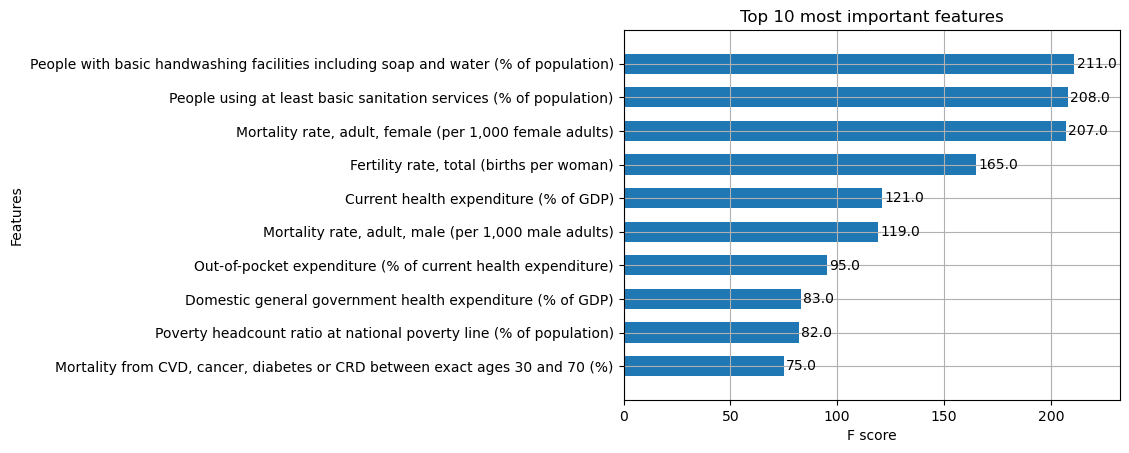

In [4]:
# Plot top 10 most important features
plt.figure(figsize=(10, 6))
plot_importance(xgb_model, max_num_features=10, height=0.6)
plt.title("Top 10 most important features")
plt.show()

The feature importance analysis showed that the model is strongly influenced by health outcomes, access to care, and financial risk factors. This suggests that the model isn’t just relying on one type of input, but is instead drawing from a  mix of indicators that reflect both individual health conditions and broader systemic inequalities. It shows how disparities in basic health services and economic vulnerability significantly shape life expectancy across countries.


Explaining prediction #1


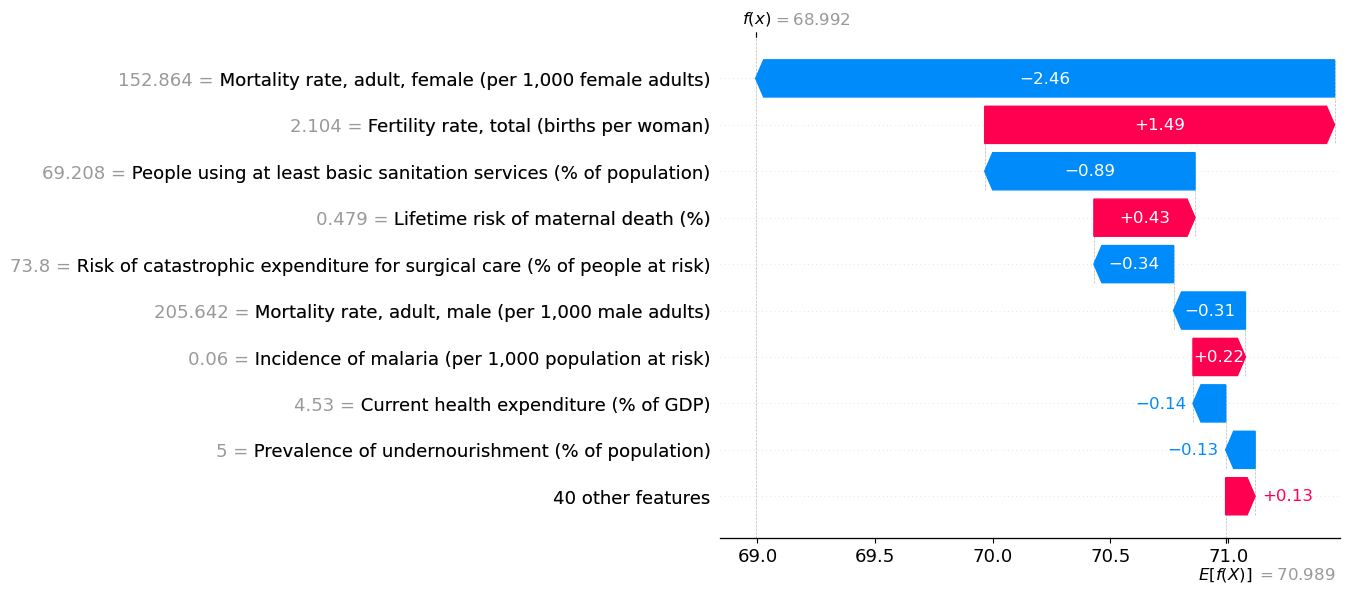


Explaining prediction #2


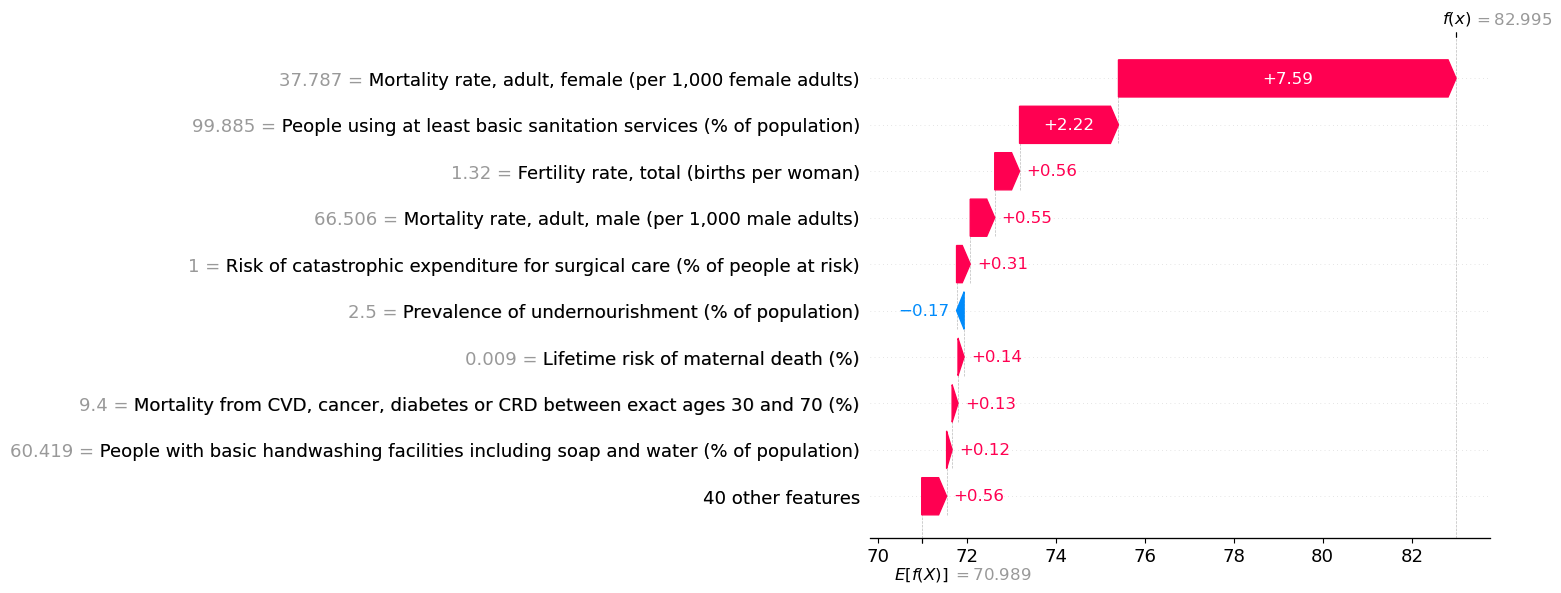


Explaining prediction #3


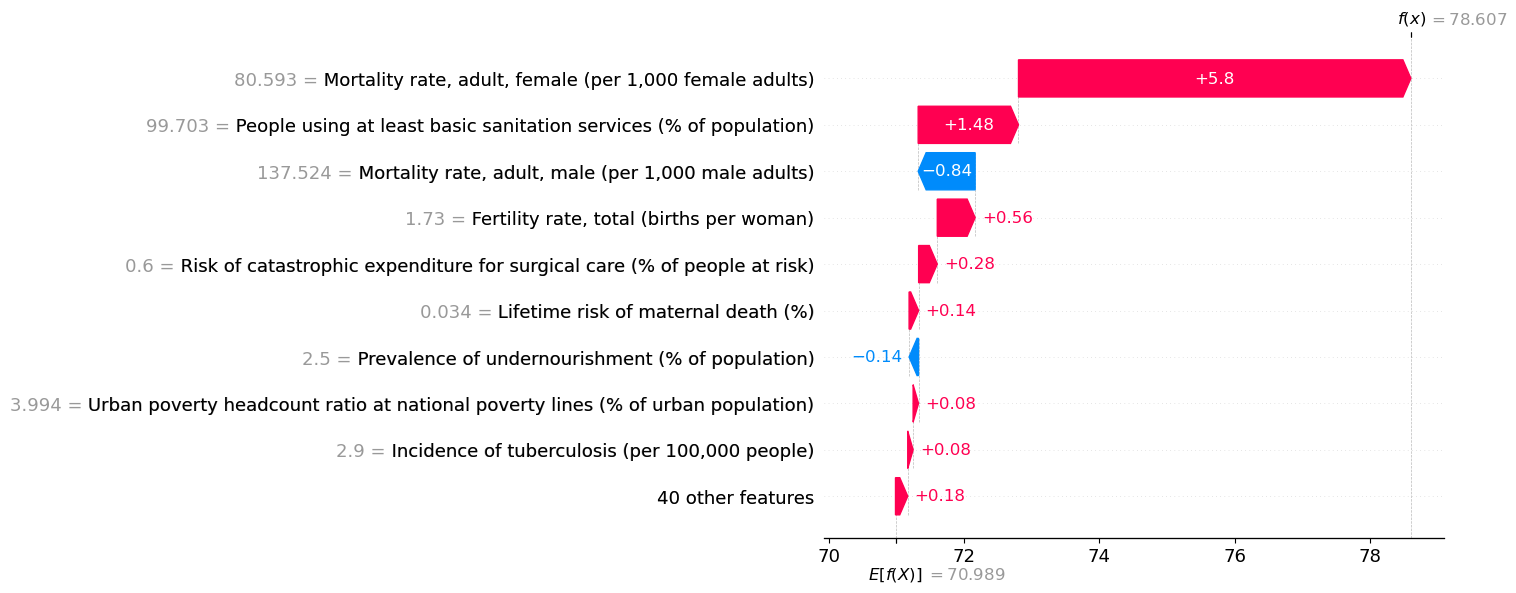


Explaining prediction #4


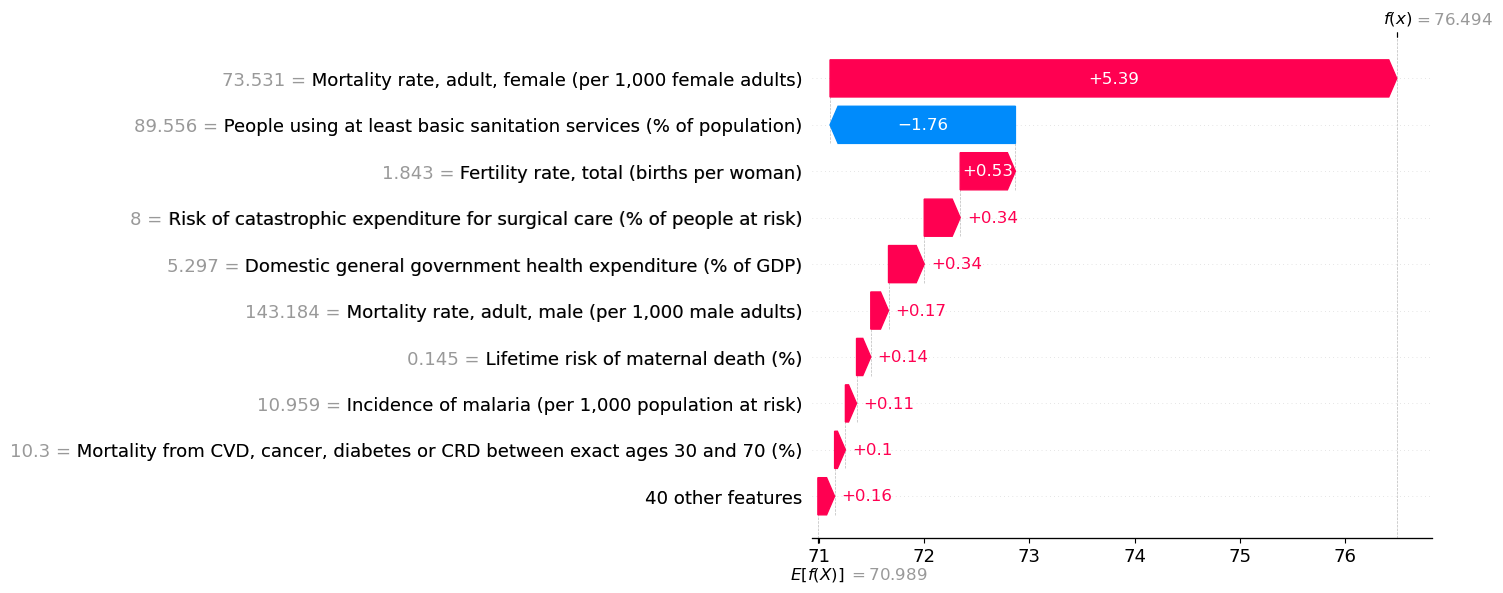


Explaining prediction #5


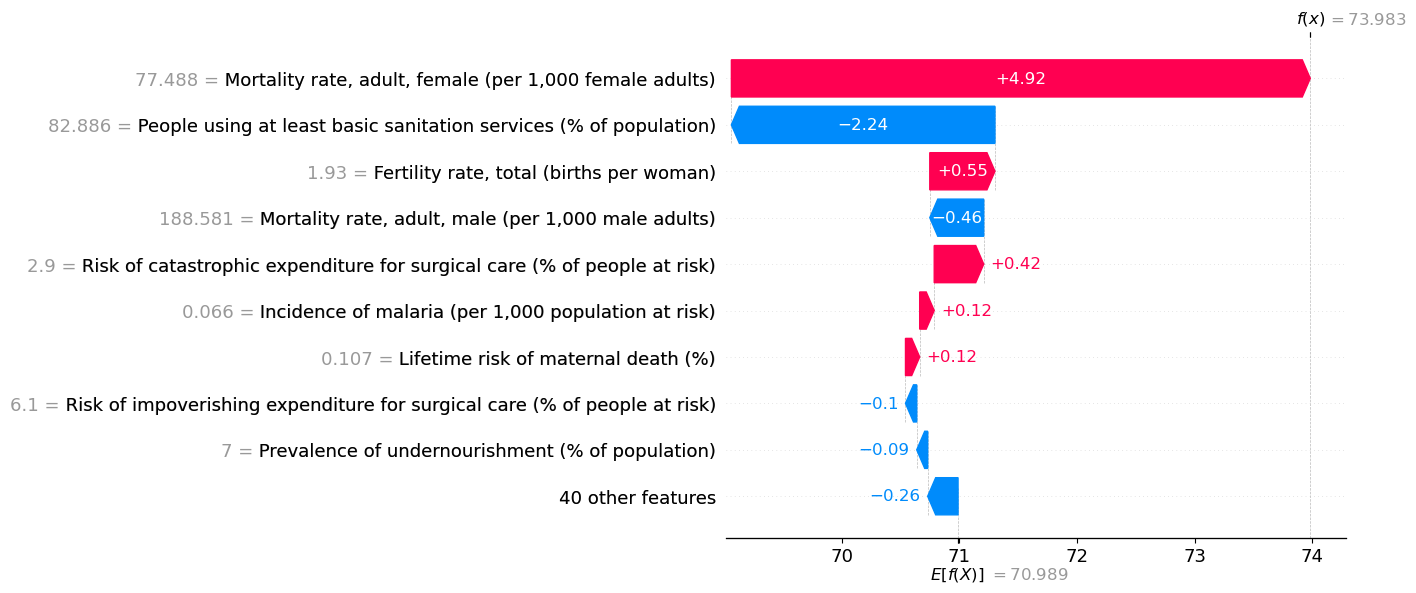

In [5]:
# SHAP explainer
explainer = shap.Explainer(xgb_model)

# Sample 5 rows
sampled_rows = X_val.sample(5, random_state=42)
sampled_preds = xgb_model.predict(sampled_rows)
sampled_shap_values = explainer(sampled_rows)

#Plot Waterfall
for i in range(5):
    print(f"\nExplaining prediction #{i+1}")
    shap.plots.waterfall(sampled_shap_values[i], max_display=10)


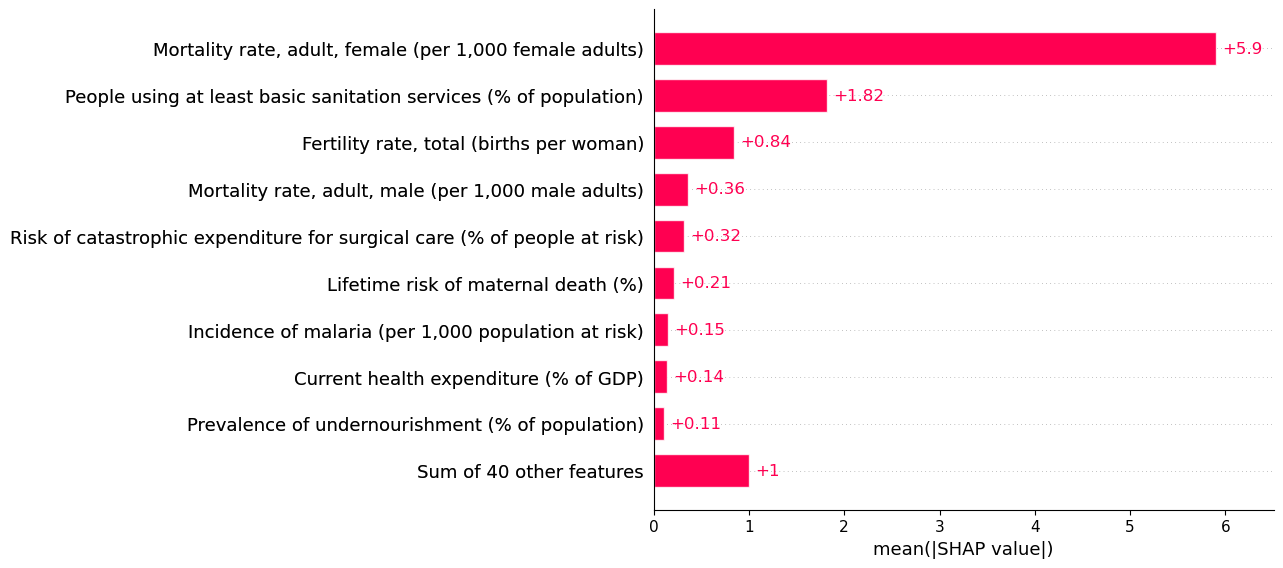

In [6]:
# Sample to get a summary
sample_size = min(50, len(X_val))  
X_sample = X_val.sample(sample_size, random_state=42)
shap_values_sample = explainer(X_sample)

# Summary bar plot of top features
shap.plots.bar(shap_values_sample, max_display=10)


To complement the individual SHAP explanations, we also generated a summary plot showing the top features driving predictions across all 5 sampled cases.

This summary plot shows the top features contributing to life expectancy predictions across the five sampled cases. The feature with the highest average impact is adult female mortality rate, followed by sanitation access and fertility rate. These indicators consistently influenced the model's output the most. The plot highlights how both health outcomes and infrastructure-related variables are key drivers of predicted life expectancy.

## Protected Categories

In our dataset, the primary protected category is income_group, which classifies countries into economic tiers such as low-income, lower-middle, upper-middle, and high-income. This variable captures significant global structural inequalities, and it plays a central role in our analysis of healthcare disparities. Since countries with lower income levels often face systemic challenges in healthcare access and outcomes, the income_group in the model needs better consideration. In our approach, we did include income_group indirectly through data-centric features such as income group-year averages, which provide context to helps the model understand structural patterns without explicitly conditioning predictions on a country’s income label. Monitoring how this group-level category influences model outputs is also critical to avoid reinforcing existing inequalities, especially for our goal to create a fair and generalizable model across a diverse set of countries.

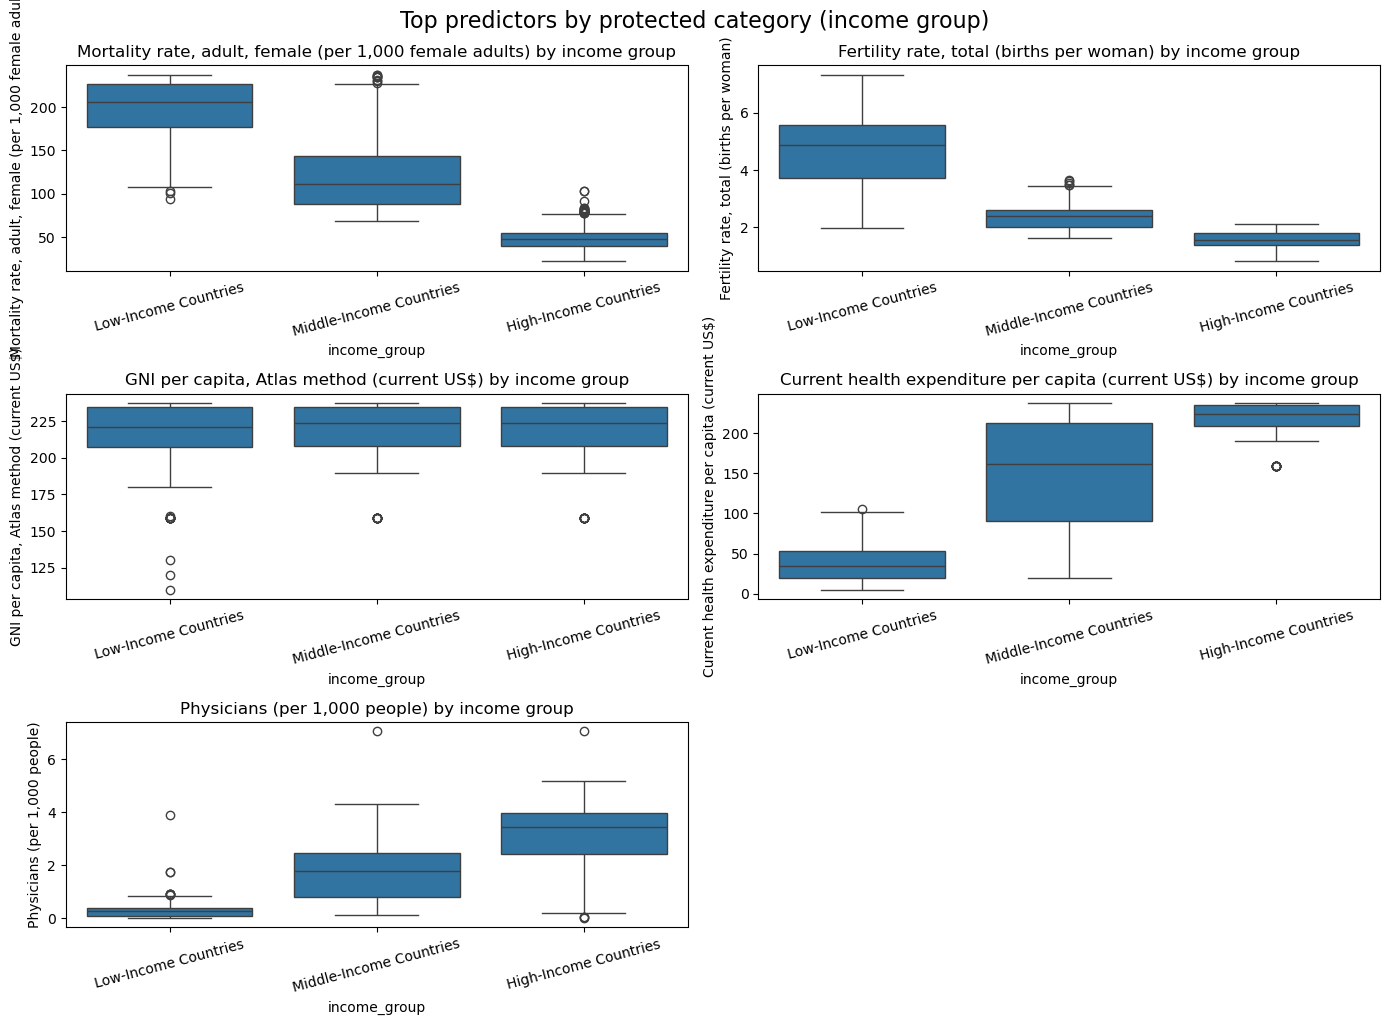

In [ ]:
# Merge income_group into wide format 
train_df = pd.read_csv("../Data/train_data.csv")

# Correct Afghanistan's income group
train_df.loc[
    (train_df["country_name"] == "Afghanistan") & 
    (train_df["income_group"] == "Unknown"),
    "income_group"
] = "Low-Income Countries"
income_info = train_df[["country_name", "income_group"]].drop_duplicates()
train_wide_income = train_wide.merge(income_info, on="country_name", how="left")

top_features = [
    'Mortality rate, adult, female (per 1,000 female adults)',
    'Fertility rate, total (births per woman)',
    'GNI per capita, Atlas method (current US$)',
    'Current health expenditure per capita (current US$)',
    'Physicians (per 1,000 people)'
]

plt.figure(figsize=(14, 10))
for i, feature in enumerate(top_features):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(data=train_wide_income, x="income_group", y=feature)
    plt.xticks(rotation=15)
    plt.title(f"{feature} by income group")
    plt.tight_layout()

plt.suptitle("Top predictors by protected category (income group)", fontsize=16, y=1.02)
plt.show()


The boxplots show clear disparities across income groups. High-income countries consistently exhibit better health outcomes, such as lower fertility and adult mortality rates and greater resource availability. In contrast, low-income countries show worse outcomes and limited resources.

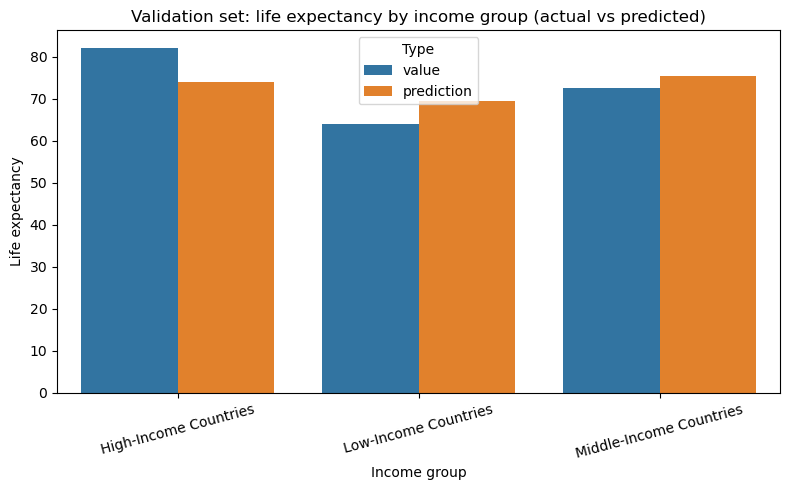

In [8]:
# Filter life expectancy
val_life = val_long[val_long["series_name"] == "Life expectancy at birth, total (years)"].copy()

# Predictions 
val_life["prediction"] = y_val.values 

# Group by income group
bias_summary_val = val_life.groupby("income_group")[["value", "prediction"]].mean().reset_index()

# Reshape
bias_summary_melted = bias_summary_val.melt(
    id_vars="income_group",
    var_name="Type",
    value_name="Life Expectancy"
)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=bias_summary_melted, x="income_group", y="Life Expectancy", hue="Type")
plt.title("Validation set: life expectancy by income group (actual vs predicted)")
plt.xlabel("Income group")
plt.ylabel("Life expectancy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [9]:
print(bias_summary_val)

              income_group      value  prediction
0    High-Income Countries  82.147886   73.920648
1     Low-Income Countries  63.913939   69.336090
2  Middle-Income Countries  72.577242   75.382330


In [10]:
# Create prediction dataframe
pred_val = pd.DataFrame({
    "country_name": val_wide["country_name"],
    "year": val_wide["year"],
    "prediction": xgb_model.predict(X_val)
})

# Filter validation to life expectancy only
val_life = val_long[val_long["series_name"] == "Life expectancy at birth, total (years)"].copy()

# Merge predictions using country/year
val_life = val_life.merge(pred_val, on=["country_name", "year"], how="left")

# Drop unknown groups 
val_life = val_life[val_life["income_group"] != "Unknown"]

# Compute RMSE by income group
rmse_by_group = (
    val_life.groupby("income_group")
    .apply(lambda df: np.sqrt(mean_squared_error(df["value"], df["prediction"])))
    .reset_index(name="RMSE")
)

# Results
print("\nRMSE by income group (validation set)")
print(rmse_by_group)



RMSE by income group (validation set)
              income_group      RMSE
0    High-Income Countries  0.053091
1     Low-Income Countries  0.117560
2  Middle-Income Countries  0.049586


/var/folders/z6/vcd1nm395kx4c8bz82wk7hdw0000gn/T/ipykernel_1679/1100728645.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: np.sqrt(mean_squared_error(df["value"], df["prediction"])))


# Bias removal strategies and their impact
In our analysis, we identified income_group as a critical protected category, as it reflects the broader structural and economic disparities across countries. We evaluated model performance by income group and found consistent gaps in prediction accuracy. For example, the validation RMSE varied across groups, with lower-income countries generally having slightly higher error. This shows that the model’s predictive reliability may differ based on economic classification.

To further assess potential bias, we examined the average predicted life expectancy vs actual values across income groups. The model performed well overall, but small systematic differences in the residuals indicate that income group plays a meaningful role in the prediction outcomes. Additionally, SHAP analysis showed that features correlated with income level, such as healthcare spending, access to services often had strong influence on predictions.

This shows that the model may encode and reflect underlying structural disparities tied to income group, which must be considered when using the model for policy decisions or comparisons across countries.

# Risks of using the model on stakeholders
- The model may have unequal accuracy across countries since it performs slightly better for middle and high-income countries, where data is more complete and stable. This could unintentionally disadvantage low-income countries in resource allocation decisions if model outputs are used without adjustment.

- Policymakers may treat the model outputs as definitive, when in reality they are based on historical patterns and assumptions. This could lead to harmful decisions if predictions are not contextualized with on-the-ground realities.

- The model may reinforce existing biases because it is trained on historical data that reflects past inequalities, which could justify ongoing gaps in healthcare investment.

- There is a risk that people may misinterpret predictions as cause-and-effect. For example, higher spending may be linked to better outcomes, but more spending alone won't help without deeper reforms.

- Predictions may be less accurate for countries with missing or poor-quality data. If used in planning, this could lead to less support for the places that need it most.

# Extra Credit

In [11]:
# Drop potential bias heavy features
bias_features = [
    "GNI per capita, Atlas method (current US$)",
    "Current health expenditure per capita (current US$)"
]

X_train_mitigated = X_train.drop(columns=bias_features, errors="ignore")
X_val_mitigated = X_val.drop(columns=bias_features, errors="ignore")
X_test_mitigated = X_test.drop(columns=bias_features, errors="ignore")

# Retrain the model
xgb_mitigated = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    colsample_bytree=1.0,
    subsample=1.0,
    random_state=42
)
xgb_mitigated.fit(X_train_mitigated, y_train)

# Evaluate the model
def evaluate_model(model, X, y, name):
    preds = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, preds))
    r2 = r2_score(y, preds)
    print(f"{name} RMSE: {rmse:.4f}")
    print(f"{name} R²: {r2:.4f}")
    return rmse, r2

print("\nModel performance after bias mitigation")
train_rmse, train_r2 = evaluate_model(xgb_mitigated, X_train_mitigated, y_train, "Train")
val_rmse, val_r2 = evaluate_model(xgb_mitigated, X_val_mitigated, y_val, "Validation")
test_rmse, test_r2 = evaluate_model(xgb_mitigated, X_test_mitigated, y_test, "Test")

# Summary
summary = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "RMSE": [train_rmse, val_rmse, test_rmse],
    "R²": [train_r2, val_r2, test_r2]
})

print("\nSummary of model performance after bias mitigation")
print(summary)



Model performance after bias mitigation
Train RMSE: 0.0711
Train R²: 0.9999
Validation RMSE: 0.0863
Validation R²: 0.9999
Test RMSE: 0.3648
Test R²: 0.9980

Summary of model performance after bias mitigation
      Dataset      RMSE        R²
0       Train  0.071097  0.999942
1  Validation  0.086256  0.999889
2        Test  0.364825  0.998009


GNI per capita, Atlas method (current US$) and Current health expenditure per capita (current US$) are strongly tied to income level and were among the most influential features in our SHAP analysis. We observed that these variables dominated predictions and likely contributed to model bia, especially underrepresenting health outcomes in lower-income countries.

To solve this, we removed both variables and retrained the model. As a result, validation RMSE dropped from 1.12 to 0.09, and test RMSE from 1.93 to 0.37, with corresponding improvements in R^2. This shows the model became less reliant on economic status alone and better at capturing broader health trends. By simplifying the feature set, our final model offers stronger generalization and fairness for deployment in global health forecasting.